# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [X] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [X] change OS to 1/10,
- [X] 1/10 OS and scf bop
- [ ] scaled bond integrals
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [4]:
target_case = 'EF_fmbcc'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_case)

Possible models are: **Kernel Ridge, MLP and Random Forest**

In [6]:
ModelName = 'Kernel Ridge'

# Targets

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


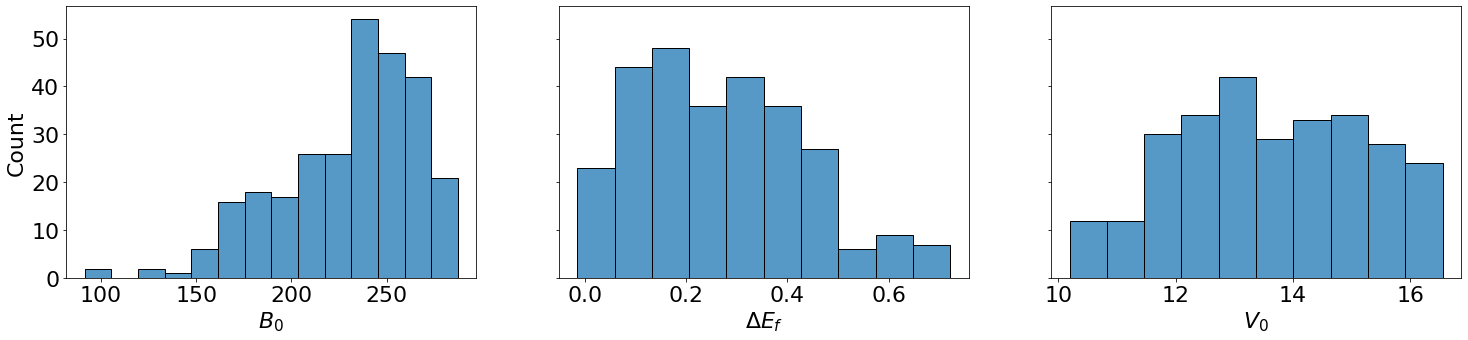

In [7]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS[target_case], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel('$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions_{target_case}.eps')

# Machine Learning 

In [8]:
from Tools.DatasetTools.MLConveniences import *

In [9]:
resultslocation = DS.resultslocation

## Feature sets

In [10]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [11]:
Features['ACE'] = Features['ACE_CNAV'].filter(regex='_0$')

## BOP features with and without CP averages

In [12]:
def clean_CNAVS(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [13]:
def clean_zeros(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [14]:
def notyetclean(name:str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [15]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name) } )

In [16]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [17]:
samplesplit = DS.get_samplesplit()

# Models: adjust params

In [18]:
import warnings
warnings.simplefilter('ignore')

In [19]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())]),
    'Gaussian Process': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [20]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [21]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

# fits

In [22]:
ModelName

'Kernel Ridge'

In [25]:
#MO.save_model_options(ModelName, ModelOptions[ModelName])

MO.load_model_options(ModelName)

#MO.modeloptions[ModelName]

samplefolds = list(DS.get_folds())

fittedmodelslocation = os.path.join(DS.resultslocation, f'{ModelName}_{target_case}__FittedCVSearch.pkl')

if os.path.exists(fittedmodelslocation):
    with open(fittedmodelslocation, 'rb') as pkl:
        FittedModels = pickle.load(pkl)
else:
    FittedModels = {}

In [26]:
FittedModels

{}

In [27]:
for name, model in Models.items():
    if name not in ModelName:
        print (name)
        continue
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        progress.set_description(key)
#        if 'BOP' not in key:
#            continue
        if 'no CNAV' in key:
            continue
        if (name, key) in FittedModels.keys():
            continue
        print(key)
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        FittedModels[(name, key)] = model.fit(features, DS.target)

with open(fittedmodelslocation, 'wb') as pkl:
    pickle.dump(FittedModels, pkl)

  0%|          | 0/24 [00:00<?, ?it/s]

atomic
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset
Fitting 5 folds for each of 96 candidates, totalling 480 fits
SOAP_canonicalFe
Fitting 5 folds for each of 96 candidates, totalling 480 fits
SOAP_canonicalW
Fitting 5 folds for each of 96 candidates, totalling 480 fits
SOAP_specific
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Pyscal
Fitting 5 folds for each of 96 candidates, totalling 480 fits
ACE_CNAV
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Canonical BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Projections BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Projections OS BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Projections sOS BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset + Canonical BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset + Projections BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fi

In [28]:
best_scores = collect_best_scores(FittedModels)

best_combi = best_scores.idxmin()['test']

best_combi

('Kernel Ridge', 'SOAP_specific')

In [29]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [30]:
best_scores.loc[best_combi]

test     4.113796e-02
train    2.559527e-09
Name: (Kernel Ridge, SOAP_specific), dtype: float64

(array([21., 41., 45., 41., 27., 36., 22.,  6., 11.,  4.]),
 array([-0.01387292,  0.06135312,  0.13657916,  0.2118052 ,  0.28703124,
         0.36225729,  0.43748333,  0.51270937,  0.58793541,  0.66316145,
         0.73838749]),
 <BarContainer object of 10 artists>)

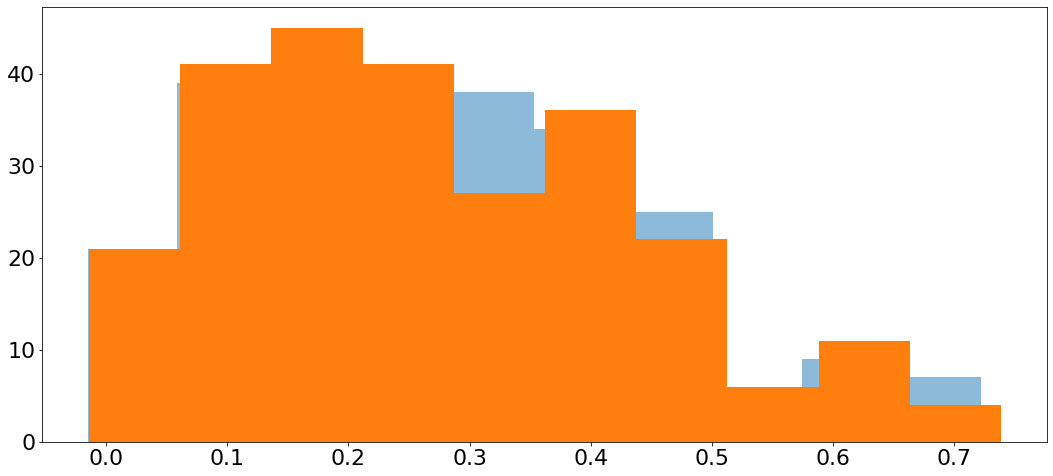

In [31]:
plt.hist(DS.target, alpha=0.5)
plt.hist(FittedModels[best_combi].predict(Features[best_combi[1]]))

for parameters in MO.modeloptions.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

In [32]:
results = pd.DataFrame.from_dict(FittedModels[(ModelName, 'dataset + Projections OS BOP')].cv_results_)#[['params','mean_test_score']]

In [33]:
results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_regressor__alpha', 'param_regressor__coef0',
       'param_regressor__degree', 'param_regressor__kernel', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')

In [34]:
results.groupby('param_regressor__degree').max()['mean_test_score']

param_regressor__degree
4   -0.041894
5   -0.042325
6   -0.042729
7   -0.043153
Name: mean_test_score, dtype: float64

In [35]:
best_scores

test         train
Kernel Ridge SOAP_specific                  0.041138  2.559527e-09
             Projections OS BOP             0.041194  1.700716e-09
             dataset + Projections OS BOP   0.041894  1.104697e-09
             dataset + Projections BOP      0.046705  7.441527e-10
             Projections BOP                0.047426  1.013992e-09
             dataset + Projections sOS BOP  0.047479  7.700078e-10
             Projections sOS BOP            0.048698  1.072913e-09
             ACE_CNAV                       0.050335  4.582593e-09
             dataset + Canonical BOP        0.054174  9.923054e-08
             dataset                        0.062926  6.046267e-10
             Canonical BOP                  0.079548  2.054438e-03
             ACE                            0.089227  3.681738e-02
             SOAP_canonicalFe               0.165759  4.846477e-02
             SOAP_canonicalW                0.165759  4.846477e-02
             atomic                         0.174036  4.439776e-02
             Pyscal                         0.186701  1.155590e-01

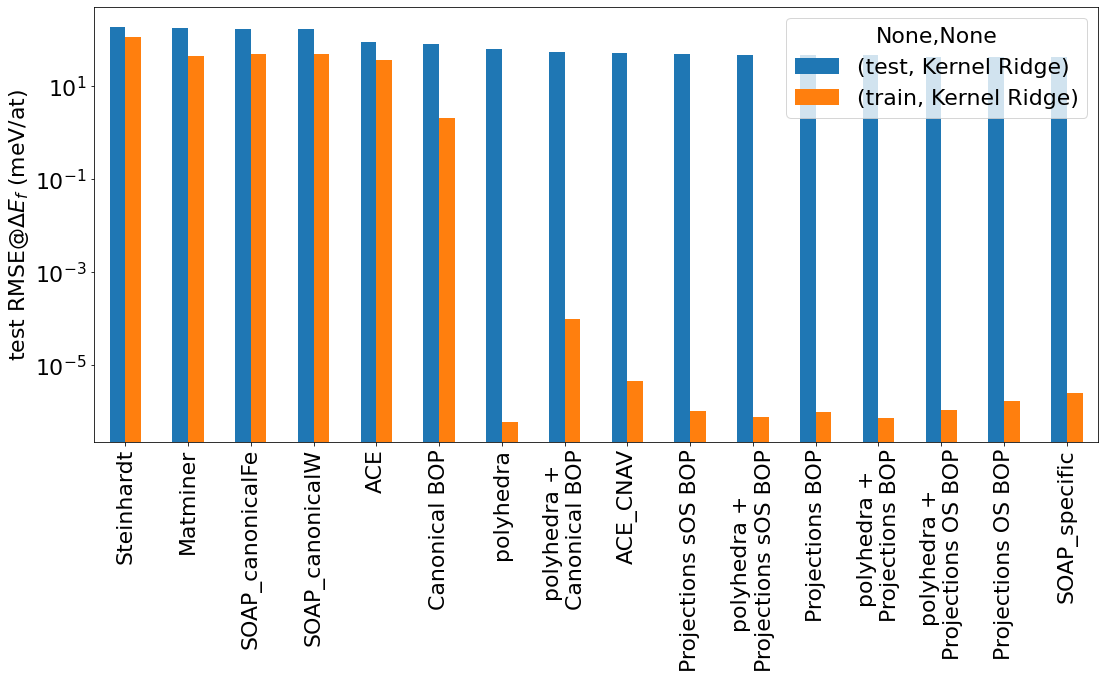

In [36]:
ax = plot_best_scores(best_scores, ModelName=ModelName)

# Recursivity

In [37]:
Tester = DatasetTester()

In [38]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#from Tools.DatasetTools.DatasetOperator import Dataset
#DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
#Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#samplesplit = DS.get_samplesplit()

In [39]:
import copy

In [40]:
RecursivityModels = copy.deepcopy(FittedModels)

In [41]:
test_scores = Tester.make_recursivity_anbn(DS, RecursivityModels, {'includemag':False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

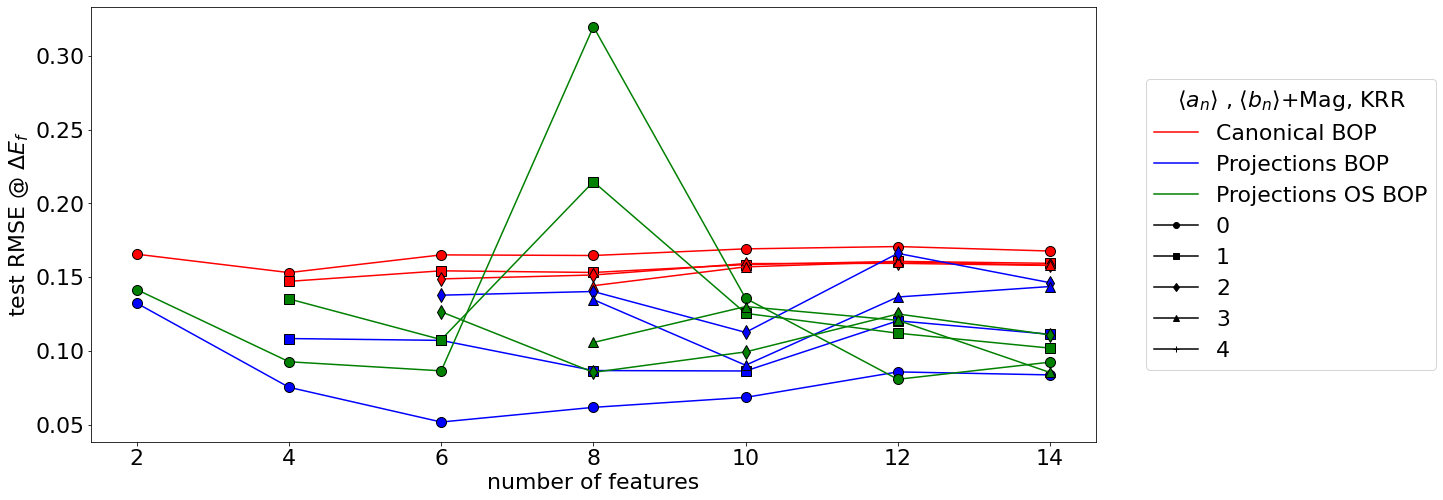

In [42]:
Tester.plot_recursivity_curve(test_scores, ModelName, )

fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{ModelName}_recursivity_anbn.pdf', bbox_inches='tight')

# Fits on reduced features 

In [43]:
ReducedFittedModels = {}

In [44]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, f'ReducedFeaturesCVSearch_{target_case}.pkl')

In [45]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

In [46]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [0.1, 0.01, 0.001, 0.0001],
  'regressor__kernel': ['rbf', 'polynomial'],
  'regressor__degree': [4, 5, 6, 7],
  'regressor__coef0': [0, 1, 10]}}

In [47]:
maxorders = [8,10,12,14,16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  #maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if (name, key,maxorder ) in ReducedFittedModels.keys():
            continue
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key :
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/120 [00:00<?, ?it/s]

In [48]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [49]:
somecombi = (ModelName, 'Projections BOP')

In [50]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [51]:
features_in = pd.Index(FittedModels[somecombi].feature_names_in_)

In [52]:
features_in.difference(features_in_reduced)

Index([], dtype='object')

In [53]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [54]:
model = best_scores_reduced.index.get_level_values(0)

In [55]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [56]:
test_scores_vs_max[ModelName]

,Projections BOP,Projections OS BOP,Projections sOS BOP,dataset + Projections BOP,dataset + Projections OS BOP,dataset + Projections sOS BOP
8,0.046858,0.039650,0.047285,0.045592,0.039262,0.045957
10,0.046987,0.040995,0.047233,0.044976,0.039894,0.045350
12,0.046778,0.040699,0.047309,0.044464,0.040408,0.045300
14,0.047479,0.040388,0.048048,0.045691,0.041079,0.046303
16,0.047426,0.041194,0.048698,0.046705,0.041894,0.047479


In [57]:
full_model_test_scores = best_scores.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


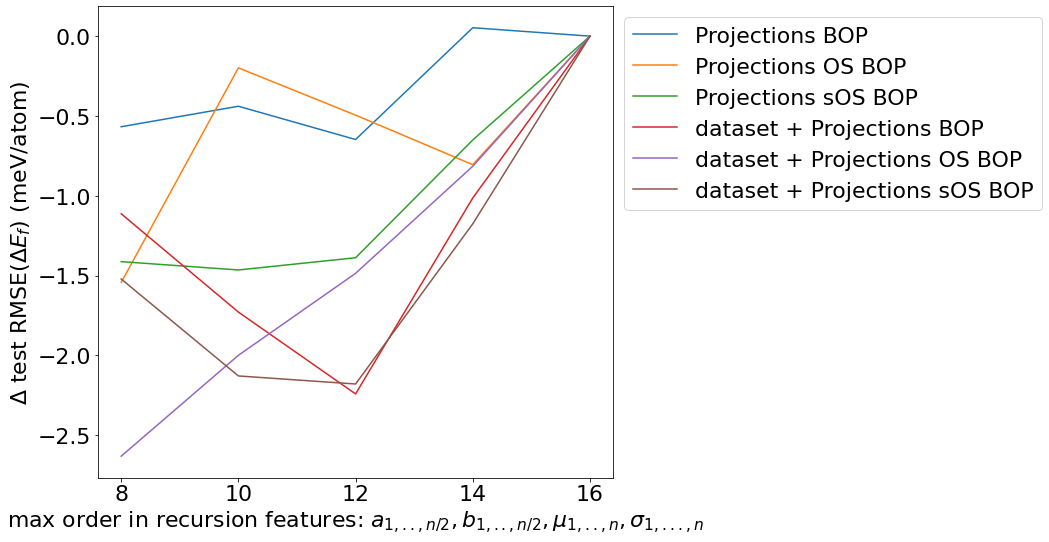

In [58]:
fig, ax = plt.subplots(figsize=(15,8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values -test_scores_vs_max[combi].values[-1])*1000 #- full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index,drmse , label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1,1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity_{target_case}.eps'))

# Feature Concatenation 

In [59]:
FeatureConcatenate = SourceFileLoader('FeatureConcatenate', 'Tools/DatasetTools/FeatureConcatenate.py').load_module().NewFeatureConcatenate
#from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate

In [60]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', f'concatenation_results_{target_case}.pkl')  
if os.path.exists(feature_concat_resul_loc):
    with open (feature_concat_resul_loc, 'rb') as pkl:
        FCresults = pickle.load(pkl)
else:
    FCresults = {}

In [63]:
#iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
#iwanttoplot = ['atomic', 
iwanttoplot = ['ACE_CNAV'] # ['ACE','ACE_CNAV', 'SOAP_specific',  'dataset', 'Canonical BOP', 'Projections OS BOP' ]#, 'Projections OS BOP', 'SOAP_canonicalW',

In [65]:
for combi, fmodel in FittedModels.items(): # DS.Features.keys(): #['Canonical BOP']:
    print (ModelName, combi)
    if (ModelName not in combi):
        continue
    if combi[-1] not in iwanttoplot:
        continue
    model = copy.deepcopy(fmodel.best_estimator_)
    if combi in FCresults.keys():
        continue
    FC =  FeatureConcatenate(DS, model, fmodel.best_params_,)
    FCresults[combi] = FC.get_best_features_list(combi[1], num_features = DS.Features[combi[1]].shape[1], max_workers=3)
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)

Kernel Ridge ('Kernel Ridge', 'atomic')
Kernel Ridge ('Kernel Ridge', 'dataset')
Kernel Ridge ('Kernel Ridge', 'SOAP_canonicalFe')
Kernel Ridge ('Kernel Ridge', 'SOAP_canonicalW')
Kernel Ridge ('Kernel Ridge', 'SOAP_specific')
Kernel Ridge ('Kernel Ridge', 'Pyscal')
Kernel Ridge ('Kernel Ridge', 'ACE_CNAV')


  0%|          | 0/1797 [00:00<?, ?it/s]

                         test     train
ace_projections_14_0  0.09703  0.111183 116.46


  0%|          | 0/1796 [00:00<?, ?it/s]

                              test     train
ace_projections_140_CN16  0.072357  0.090684 79.71


  0%|          | 0/1795 [00:00<?, ?it/s]

                             test     train
ace_projections_15_CN16  0.062571  0.077137 80.32


  0%|          | 0/1794 [00:00<?, ?it/s]

Process ForkProcess-12:
Traceback (most recent call last):
  File "/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
Process ForkProcess-10:
Process ForkProcess-11:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Exception in thread Thread-10:
Traceback (most recent call last):
  File "/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/threading.py", line 980, in _bootstrap_inner
    self.run()
  File "/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/concurrent/futures/process.py", line 323, in run
    self.terminate_broken(cause)
  File "/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/con

KeyboardInterrupt: 

In [54]:
FCresults[('Kernel Ridge','Projections OS BOP')].index.get_loc('Mag')

56

In [55]:
FCresults[('Kernel Ridge','Projections sOS BOP')].test.min()

0.01502711495407399

In [56]:
FCresults[('Kernel Ridge','SOAP_specific')].test.min()

0.01749545561305998

In [57]:
FCresults[('Kernel Ridge','SOAP_canonicalW')].test.min()

0.12897885869643316

In [58]:
from Tools.DatasetTools.Tools import get_str_formatted

In [59]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [60]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

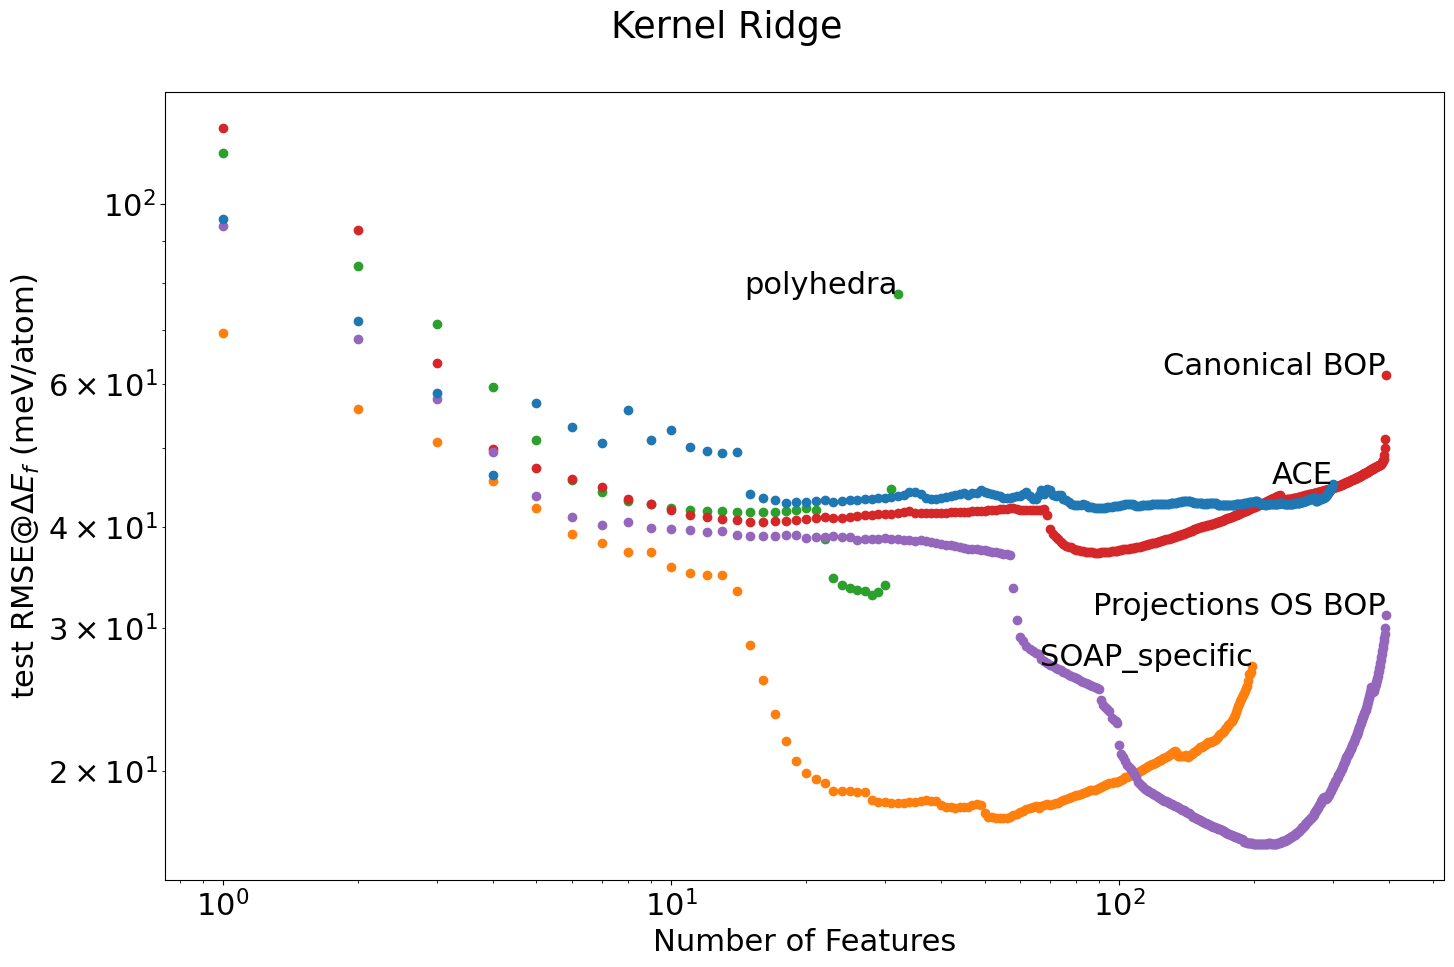

In [61]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(figsize=(15,10))
for combi, result in FCresults.items():
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result.shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')
    y = result['test']*1000
    axes.plot(x, y ,'o',c=colors[combi[1]], label=legend)
    axes.text(x[-1], y[-1], legend, horizontalalignment='right')
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))

axes.set_yscale('log')
#plt.legend(bbox_to_anchor=(0.6,0.5))
fig.suptitle(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_{target_case}.pdf')

In [ ]:
FCresults

In [ ]:
selected_pos = FCresults[(ModelName, 'Projections sOS BOP')].index[0]
y_pos = FCresults[(ModelName, 'Projections sOS BOP')]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[(ModelName, 'Projections sOS BOP')].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-40), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated_{target_case}.pdf')

## selections

In [ ]:
mask = FCresults[(ModelName, 'Projections sOS BOP')].index.str.contains('Structure')

In [ ]:
FCresults[(ModelName, 'Projections OS BOP')].loc[mask]

# Final learn after feature selection 

In [ ]:
OptimalFittedScores = {}
OptimalFittedModels = {}

In [ ]:
Models[ModelName]

In [ ]:
for combi in FCresults.keys():
    if ModelName not in combi:
        continue
    if combi not in FittedModels.keys():
        continue
    OptimalFittedModels[combi]  = copy.deepcopy(Models[ModelName])
    params = FittedModels[combi].best_params_
    OptimalFittedModels[combi].set_params(**params) #= GridSearchCV(amodel, MO.modeloptions[ModelName], scoring = 'neg_root_mean_squared_error',return_train_score=True)
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    if 'random' in selected:
        print(f'random selected in {combi}')
    #if 'random' in selected:
    #    selected = selected.drop('random')
    OptimalFittedModels[combi].fit(X.loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])
    OptimalFittedScores[combi] = score_fitted_model(OptimalFittedModels[combi], X.loc[DS.samplesplit['train']], X.loc[DS.samplesplit['test']], DS.target[DS.samplesplit['train']], DS.target[DS.samplesplit['test']] )


In [ ]:
OptimalFittedScores = pd.DataFrame.from_dict(OptimalFittedScores, orient='index')#.sort_values(by='test')
OptimalFittedScores.sort_values(by='test', ascending=False, inplace=True)

In [ ]:
OptimalFittedFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalModels_{target_case}.pkl'
with open(OptimalFittedFile, 'wb') as pkl:
    pickle.dump(OptimalFittedModels, pkl)
OptimalFittedScoresFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalScores_{target_case}.pkl'
with open(OptimalFittedScoresFile, 'wb') as pkl:
    pickle.dump(OptimalFittedScores, pkl)


In [ ]:
plot_best_scores = SourceFileLoader('plot_best_scores', 'Tools/DatasetTools/MLConveniences.py').load_module().plot_best_scores

ax = plot_best_scores(OptimalFittedScores, ModelName=ModelName)
ax.tick_params(axis='y', which = 'minor')
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.legend(title='')

# Prediction line 

In [ ]:
Prediction = {}
for combi, model in OptimalFittedModels.items():
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    Prediction[combi] = model.predict(X)

In [ ]:
#iwanttoplot = {'atomic':'Matminer',
#iwanttoplot = {'Canonical BOP': 'Canonical BOP', 'Projections sOS BOP':'Projections sOS BOP'}
iwanttoplot = {'dataset': 'dataset', 'Projections OS BOP':'Projections OS BOP'}

In [ ]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi], DS.target, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend)
#    sns.scatterplot(Prediction[name], DS.target,ax=ax) #, markersize=8, markeredgecolor='k',  color = color, label=legend)
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline_{target_case}.pdf'))

# Feature Importances 

In [ ]:
importances = {}
for combi, estimator in OptimalFittedModels.items():
    print(combi[1])
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    if 'random' in selected:
        print(f'random selected in {combi}')
    X = DS.Features[combi[1]][selected]
    allimportances = get_importances(estimator , X,  DS.target)
    importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]

In [ ]:
for (modelname, name),timportances in importances.items():
    timportances.sort_values(by='importances_mean', inplace=True, ascending=False)

In [ ]:
#for (model, name), timp in importances.items():
for (model, name), timp in importances.items(): #['Projections OS BOP', 'dataset + Projections OS BOP']:
#    pimp = timp[timp.index != 'Mag']
    fig, ax = plt.subplots(figsize=(18, 15))
    x = timp['importances_mean'][:20]
    sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
    ylabels = [get_str_formatted(fname) for fname in x.index]
    ax.set_xlabel('permutation importance')
    ax.set_yticklabels(ylabels, fontsize=28)
    fig.suptitle(name.replace('dataset', 'polyhedra'))
    fig.tight_layout()
    nameforfile  = name.replace(' ','')
    fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_permutation_importance_{nameforfile}.pdf')

# Errors by phase  

In [ ]:
combi = (ModelName, 'Projections OS BOP')

In [ ]:
model = OptimalFittedModels[combi]

In [ ]:
nselected = FCresults[combi]['test'].argmin()

In [ ]:
selected = FCresults[combi].index[:nselected]

In [ ]:
predictions = model.predict(DS.Features[combi[1]][selected])

In [ ]:
train_errors = np.abs(predictions - DS.target)

In [ ]:
rmse = {}

In [ ]:
for phase in DS.BS.Phase.unique():
    thiserrors = train_errors[DS.BS.Phase == phase]**2
    rmse[phase] =  np.sqrt(thiserrors.sum()/len(thiserrors))*1000

In [ ]:
fig, ax = plt.subplots(3, 1, sharex = True)
tphase = ax[0].hist(train_errors[DS.BS.Phase == 'C36'], bins=10, color='red', label='C36')
tphase = ax[1].hist(train_errors[DS.BS.Phase == 'sigma'], bins=10,color='blue', label = r'$\sigma$')
tphase = ax[2].hist(train_errors[DS.BS.Phase == 'mu'], bins=10, color='purple', label = r'$\mu$')
fig.legend()

# Errors by Mag 

In [ ]:
fm_errors = train_errors[train_errors.index.str.contains('FM$',regex=True)]

In [ ]:
nm_errors = train_errors[train_errors.index.str.contains('NM$',regex=True)]

In [ ]:
ax = nm_errors.hist()
fm_errors.hist(ax=ax)
ax.set_xlabel(r'$\Delta E_{FM} - \Delta E_{NM}$')

# convex hulls (binaries only)

In [ ]:
from Tools.DatasetTools.Tools import Plotting
P = Plotting()

In [ ]:
from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

In [ ]:
components = DS.components

In [ ]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [ ]:
predictedBS['EF'] = Prediction[combi]

In [ ]:
PhaseBS = {}
verts = {}
chulls = {}
phasepoints = {}

PhaseBS = {phase: DS.BS[DS.BS.Phase == phase] for phase in DS.BS.Phase.unique()}

points = P.get_x_ef_points(PhaseBS, components)
chulls = P.get_convex_hulls(PhaseBS, components, return_points = False)

In [ ]:
PredPhaseBS = {}
Predverts = {}
Predchulls = {}
Predphasepoints = {}

PredPhaseBS = {phase: predictedBS[DS.BS.Phase == phase] for phase in DS.BS.Phase.unique()}

predpoints = P.get_x_ef_points(PredPhaseBS, components)
predchulls = P.get_convex_hulls(PredPhaseBS, components, return_points = False)

In [ ]:
iwanttoplot_inchull = ['R', 'mu', 'C14', 'C36','sigma']

In [ ]:
pallette = sns.color_palette("icefire", n_colors=len(iwanttoplot))
colors = {phase: color for phase, color in zip(iwanttoplot, pallette)}
fig, ax = plt.subplots()
labels=[]
handles = []
for phase, chull in chulls.items():
    if phase not in iwanttoplot_inchull:
        continue
    for visible_facet in chull.simplices[chull.good]:
#        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase], lw=2)
    handles.append(l[0])
    labels.append(phase)
    for visible_facet in predchulls[phase].simplices[predchulls[phase].good]:
#        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(predchulls[phase].points[visible_facet,0], predchulls[phase].points[visible_facet,1],'--o', color=colors[phase], lw=2, ms=10)
leg = ax.legend(handles +[Line2D([],[], linestyle='--',marker='o', color='black')], labels+[f'{ModelName} \n Predictions'], bbox_to_anchor=(1.01,1))
setlw = [ha.set_linewidth(5) for ha in leg.get_lines()[:-1] ]
ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
ax.set_xlabel(rf'$x_{{{components[0]}}}$')
ax.axhline(color='black', linestyle='--')
ax.set_xlim([0,1])
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(os.path.join(DS.dataset, 'graphs',f'{DS.dataset}_{nameforfile}_ConvxHullsFinal_{target_case}.eps' ))